# Pilot win-rate analysis

Homogeneous vs. heterogeneous multi-agent paper review — **Stage 1 pilot** results.

This notebook reads `eval/results/<run-set>/win_rate.json` and renders the overall
ranking, the capability precondition, role-localization, and the assignment contrast.
It is parametrised by `RUN_SET` (cell below), so the same notebook can be re-run on the
held-out `full` set once that exists.

**Pilot setup:** 12 configs (3 homogeneous references + 9 heterogeneous) × 5 papers,
position-debiased side-by-side judging (both presentation orders). Pool: `A = qwen/qwen3-32b`,
`B = mistral-small-3.2-24b`, `C = llama-3.3-70b`. Each config is a 4-tuple
`(leader, clarity, experiments, impact)`.

> Pilot caveats: a **single** judge (`gpt-5-mini`; `deepseek-v3.2` not run) over **5**
> papers. Good enough to *prune*, not to make significance claims — that is what the
> 25-paper / 2-judge `full` run is for.

In [1]:
# Canonical setup skeleton for eval/analysis notebooks.
# Style tokens: .cursor/skills/eval-notebook-style/

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUN_SET = "pilot"  # or "pilot"

ROOT = Path.cwd()
while not (ROOT / "eval").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

RESULTS_DIR = ROOT / "eval" / "results" / RUN_SET
BATCHES = ROOT / "eval" / "batches.json"
FIG_DIR = ROOT / "eval" / "analysis" / "figures" / RUN_SET
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- palette (seaborn deep quad) ---
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
MODEL_COLORS = {"A": PALETTE[0], "B": PALETTE[1], "C": PALETTE[2]}
MODEL_NAMES = {"A": "qwen3-32b", "B": "mistral-small-3.2", "C": "llama-3.3-70b"}
ROLE_COLORS = dict(zip(
    ("leader", "clarity", "experiments", "impact"), PALETTE
))
ROLES = ("leader", "clarity", "experiments", "impact")
C_HET, C_REF = PALETTE[0], PALETTE[1]  # blue het, orange ref
C_ANNOT, C_MUTED, C_REF_LINE, C_EDGE, C_ERR = (
    "#333333", "#555555", "#666666", "#FFFFFF", "#333333",
)
# --- layout constants (fixed legend gap from figure bottom) ---
LEGEND_Y = 0.035          # figure coords — same on every plot
MARGIN_NO_LEGEND = 0.12
MARGIN_LEGEND = 0.22      # barh / scatter with legend, no rotated x
MARGIN_XROT30 = 0.28
MARGIN_XROT45 = 0.32
MARGIN_HEATMAP = 0.28
SAVE_PAD = 0.12


def legend_bottom(*, xrot=0, titled=False):
    if xrot >= 40:
        b = MARGIN_XROT45
    elif xrot >= 20:
        b = MARGIN_XROT30
    else:
        b = MARGIN_LEGEND
    if titled:
        b += 0.04
    return b


def legend_below(
    fig, ax=None, *, handles=None, labels=None, ncol=2, title=None, xrot=0,
):
    """Figure-level legend at fixed LEGEND_Y. Returns bottom margin for save_fig."""
    if handles is None:
        if ax is None:
            raise ValueError("legend_below needs ax or explicit handles")
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()
        handles, labels = ax.get_legend_handles_labels()
    kw = dict(
        loc="lower center", bbox_to_anchor=(0.5, LEGEND_Y), ncol=ncol,
        fontsize=8, framealpha=0.95, edgecolor="#CCCCCC", frameon=True,
    )
    if title:
        kw["title"] = title
    fig.legend(handles, labels, **kw)
    return legend_bottom(xrot=xrot, titled=title is not None)


def annotate_configs(ax, x, y, configs, *, fontsize=7, offsets_by_name=None):
    """Config slug near each scatter point."""
    defaults = [
        (7, 5), (7, -7), (-7, 5), (-7, -7),
        (10, 0), (-10, 0), (0, 9), (0, -9),
    ]
    for i, (xi, yi, name) in enumerate(zip(x, y, configs)):
        dx, dy = (offsets_by_name or {}).get(name, defaults[i % len(defaults)])
        ax.annotate(
            name, (xi, yi), textcoords="offset points", xytext=(dx, dy),
            fontsize=fontsize, color=C_ANNOT,
            ha="left" if dx >= 0 else "right",
            va="bottom" if dy >= 0 else "top",
        )


def pad_axes_for_labels(ax, *, xfrac=0.06, yfrac=0.08):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    ax.set_xlim(x0 - (x1 - x0) * xfrac, x1 + (x1 - x0) * xfrac)
    ax.set_ylim(y0 - (y1 - y0) * yfrac, y1 + (y1 - y0) * yfrac)


def save_fig(fig, path, *, bottom=MARGIN_NO_LEGEND, top=0.90, left=None, right=None):
    kw = dict(bottom=bottom, top=top)
    if left is not None:
        kw["left"] = left
    if right is not None:
        kw["right"] = right
    fig.subplots_adjust(**kw)
    fig.savefig(path, bbox_inches="tight", pad_inches=SAVE_PAD)


LEGEND_KW = dict(
    loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2,
    fontsize=8, framealpha=0.95, edgecolor="#CCCCCC", frameon=True,
)

FIG_RANK, FIG_COMPACT = (8.5, 4.5), (6, 3.6)
FIG_SCATTER, FIG_PANEL, FIG_WIDE = (7, 5), (9.5, 3.8), (12, 4.0)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 8,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.alpha": 0.25, "grid.color": "#E0E0E0", "grid.linestyle": "-",
    "lines.linewidth": 1.5, "patch.linewidth": 0.5,
})


def fig_title(desc: str, *, n_papers: int | None = None, extra: str = "") -> str:
    """Notebook title — keep light; LaTeX captions carry detail."""
    parts = []
    if RUN_SET == "pilot":
        parts.append("pilot")
    if n_papers is not None and (RUN_SET == "pilot" or n_papers != 25):
        parts.append(f"n={n_papers} papers")
    if extra:
        parts.append(extra)
    return f"{desc} ({', '.join(parts)})" if parts else desc


batch = json.loads(BATCHES.read_text())[RUN_SET]
pool = batch["pool"]
slug_to_letter = {v: k for k, v in pool.items()}


def letter(value: str) -> str:
    if value in pool:
        return value
    return slug_to_letter.get(value, value)


def tuple_letters(cfg: str) -> tuple[str, ...]:
    m = batch["configs"][cfg]
    return tuple(letter(m[r]) for r in ROLES)


def is_homogeneous(cfg: str) -> bool:
    return len(set(tuple_letters(cfg))) == 1



RESULTS = RESULTS_DIR / "win_rate.json"
READY = RESULTS.exists()

if not READY:
    print(f"win_rate.json not found at {RESULTS}")
    wr = None
    df = pd.DataFrame()
else:
    wr = json.loads(RESULTS.read_text())

    rows = []
    for c in wr["per_config"]:
        t = tuple_letters(c)
        rows.append({
            "config": c,
            "tuple": ",".join(t),
            "leader": t[0], "clarity": t[1], "experiments": t[2], "impact": t[3],
            "homogeneous": len(set(t)) == 1,
            "win_rate": wr["per_config"][c]["overall"],
        })

    df = pd.DataFrame(rows).sort_values("win_rate", ascending=False).reset_index(drop=True)

    judges = ", ".join(wr["judges"])
    n_papers = len({rc["paper_id"] for rc in wr["raw_comparisons"]})
    best_homo = df.loc[df["homogeneous"], "win_rate"].max()

    print(f"run-set    : {RUN_SET}")
    print(f"judge(s)   : {judges}")
    print(f"papers     : {n_papers}")
    print(f"configs    : {len(df)}  ({int(df['homogeneous'].sum())} homogeneous references)")
    print(f"comparisons: {len(wr['raw_comparisons'])}  ({len(wr['pairwise'])} unordered pairs x 2 orders)")
    print(f"best homogeneous win-rate: {best_homo:.3f}")



run-set    : pilot
judge(s)   : openai/gpt-5-mini
papers     : 5
configs    : 12  (3 homogeneous references)
comparisons: 660  (66 unordered pairs x 2 orders)
best homogeneous win-rate: 0.809


## 1. Overall ranking

Win-rate = share of head-to-head judgments a config wins (ties count 0.5), aggregated
across every opponent, paper, judge, and presentation order. The dashed line is the best
homogeneous reference — anything to its right is a heterogeneous config that beats "just
use the strongest single model everywhere".

In [2]:
disp = df.copy()
disp.index = np.arange(1, len(disp) + 1)
disp["kind"] = np.where(disp["homogeneous"], "reference", "heterogeneous")
disp[["config", "tuple", "kind", "win_rate"]]

,config,tuple,kind,win_rate
1,specialist,"A,B,A,C",heterogeneous,0.836364
2,All-A,"A,A,A,A",reference,0.809091
3,swap_experiments,"B,B,A,B",heterogeneous,0.740909
4,rot_2,"B,C,A,B",heterogeneous,0.677273
5,swap_leader,"A,B,B,B",heterogeneous,0.609091
6,swap_clarity,"B,A,B,B",heterogeneous,0.495455
7,rot_3,"B,B,C,A",heterogeneous,0.481818
8,swap_impact,"B,B,B,A",heterogeneous,0.477273
9,anti_specialist,"B,A,C,B",heterogeneous,0.436364
10,All-B,"B,B,B,B",reference,0.213636


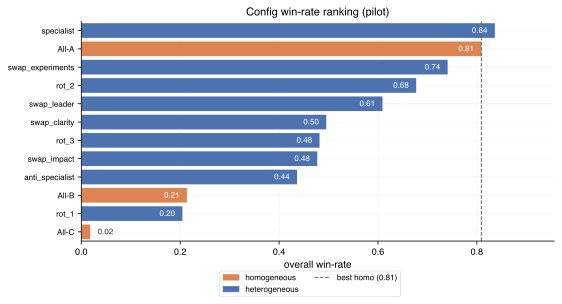

In [3]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

d = df.sort_values("win_rate")
colors = [C_REF if h else C_HET for h in d["homogeneous"]]
bar_y = np.arange(len(d))
labels = d["config"].tolist()
x_right = max(d["win_rate"].max(), best_homo) + 0.12

fig, ax = plt.subplots(figsize=FIG_RANK)
ax.barh(bar_y, d["win_rate"], color=colors)
ax.axvline(best_homo, ls="--", color=C_REF_LINE, lw=1)
ax.set_yticks(bar_y)
ax.set_yticklabels(labels, fontsize=8)
for yi, v in enumerate(d["win_rate"]):
    txt = f"{v:.2f}"
    if v >= 0.06:
        ax.text(v - 0.015, yi, txt, va="center", ha="right", fontsize=8, color="white")
    else:
        ax.text(v + 0.015, yi, txt, va="center", ha="left", fontsize=8, color=C_ANNOT)

ax.set_xlim(0, x_right)
ax.set_ylim(-0.5, len(d) - 0.5)
ax.set_xlabel("overall win-rate")
ax.set_title(fig_title("Config win-rate ranking"))
handles = [
    Patch(color=C_REF, label="homogeneous"),
    Patch(color=C_HET, label="heterogeneous"),
    Line2D([0], [0], ls="--", color=C_REF_LINE, lw=1,
           label=f"best homo ({best_homo:.2f})"),
]
bottom = legend_below(fig, handles=handles,
                      labels=[h.get_label() for h in handles], ncol=2)
save_fig(fig, FIG_DIR / "ranking.png", bottom=bottom)
plt.show()


## 2. Capability precondition

Before reading anything into heterogeneity, check the spread of the homogeneous
references. If one model runs away, every heterogeneous result must be framed relative
to it (per `PLAN.md`).

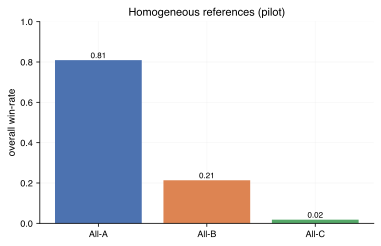

spread: {'All-A': 0.809, 'All-B': 0.214, 'All-C': 0.018}


In [4]:
homo = df[df["homogeneous"]].copy()
homo["model"] = homo["leader"]
homo = homo.sort_values("win_rate", ascending=False)

fig, ax = plt.subplots(figsize=FIG_COMPACT)
bars = ax.bar(homo["config"], homo["win_rate"],
              color=[MODEL_COLORS[m] for m in homo["model"]])
for b, v in zip(bars, homo["win_rate"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
ax.set_ylim(0, 1.0)
ax.set_ylabel("overall win-rate")
ax.set_title(fig_title("Homogeneous references"))
save_fig(fig, FIG_DIR / "win_rate_capability.png", bottom=MARGIN_NO_LEGEND)
plt.show()

print("spread:", {r.config: round(r.win_rate, 3) for r in homo.itertuples()})


## 3. Localization — which seat's model matters?

Colour each config by the model sitting in the **experiments** seat. If the high-win-rate
configs cluster on one model, that seat is doing the work. The mean win-rate grouped by
experiments-seat model makes the effect explicit.

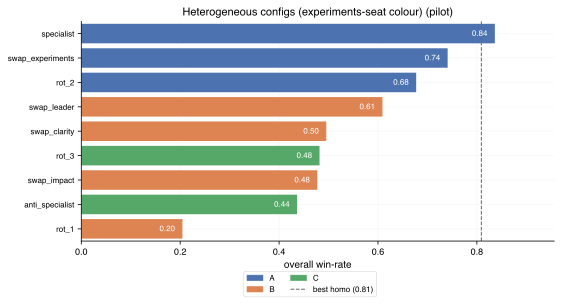

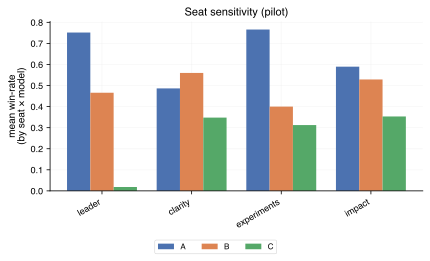

mean win-rate by (seat, model):


,A,B,C
leader,0.752,0.466,0.018
clarity,0.486,0.560,0.348
experiments,0.766,0.400,0.312
impact,0.589,0.529,0.353


In [5]:
from matplotlib.lines import Line2D

het = df[~df["homogeneous"]].sort_values("win_rate")

fig, ax = plt.subplots(figsize=FIG_RANK)
labels = het["config"].tolist()
bar_y = np.arange(len(het))
x_right = max(het["win_rate"].max(), best_homo) + 0.12
ax.barh(bar_y, het["win_rate"], color=[MODEL_COLORS[m] for m in het["experiments"]])
ax.axvline(best_homo, ls="--", color=C_REF_LINE, lw=1)
ax.set_yticks(bar_y)
ax.set_yticklabels(labels, fontsize=8)
for yi, v in enumerate(het["win_rate"]):
    txt = f"{v:.2f}"
    if v >= 0.06:
        ax.text(v - 0.015, yi, txt, va="center", ha="right", fontsize=8, color="white")
    else:
        ax.text(v + 0.015, yi, txt, va="center", ha="left", fontsize=8, color=C_ANNOT)
ax.set_xlim(0, x_right)
ax.set_ylim(-0.5, len(het) - 0.5)
ax.set_xlabel("overall win-rate")
ax.set_title(fig_title("Heterogeneous configs (experiments-seat colour)"))
handles = [
    plt.Rectangle((0, 0), 1, 1, color=MODEL_COLORS[m]) for m in ("A", "B", "C")
] + [Line2D([0], [0], ls="--", color=C_REF_LINE, lw=1)]
labels_leg = ["A", "B", "C", f"best homo ({best_homo:.2f})"]
bottom = legend_below(fig, handles=handles, labels=labels_leg, ncol=2)
save_fig(fig, FIG_DIR / "het_experiments.png", bottom=bottom)
plt.show()


seat_means = {role: df.groupby(role)["win_rate"].mean() for role in ROLES}
seat_df = pd.DataFrame(seat_means).T.reindex(columns=["A", "B", "C"])

fig, ax = plt.subplots(figsize=(7.2, 3.8))
x = np.arange(len(ROLES)); w = 0.26
for letter in ("A", "B", "C"):
    ax.bar(x + (["A", "B", "C"].index(letter) - 1) * w, seat_df[letter].values, w,
           label=letter, color=MODEL_COLORS[letter])
ax.set_xticks(x)
ax.set_xticklabels(ROLES, rotation=30, ha="right")
ax.set_ylabel("mean win-rate\n(by seat × model)")
ax.set_title(fig_title("Seat sensitivity"))
bottom = legend_below(fig, ax, ncol=3, xrot=30)
save_fig(fig, FIG_DIR / "seat_sensitivity.png", bottom=bottom, left=0.18)
plt.show()

print("mean win-rate by (seat, model):")
seat_df.round(3)


## 4. Assignment & full pairwise matrix

`pairwise` stores each unordered pair once as the row-config's win-rate over the
column-config; the mirror cell is `1 - x` (wins + ties sum to 1). The `specialist` vs
`anti_specialist` cell is the assignment contrast: similar model set, different seating.

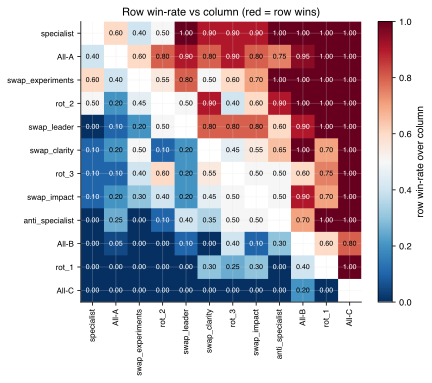

In [6]:
order = df["config"].tolist()
idx = {c: i for i, c in enumerate(order)}
n = len(order)
M = np.full((n, n), np.nan)

for key, val in wr["pairwise"].items():
    a, b = key.split("__vs__")
    if a in idx and b in idx:
        wa = val["overall"]
        M[idx[a], idx[b]] = wa
        M[idx[b], idx[a]] = 1 - wa

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(M, cmap="RdBu_r", vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(order, rotation=90, fontsize=8)
ax.set_yticks(range(n)); ax.set_yticklabels(order, fontsize=8)
for i in range(n):
    for j in range(n):
        if not np.isnan(M[i, j]):
            ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(M[i, j] - 0.5) > 0.32 else "black")
ax.set_title("Row win-rate vs column (red = row wins)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="row win-rate over column")
save_fig(fig, FIG_DIR / "pairwise.png", bottom=MARGIN_HEATMAP, top=0.88)
plt.show()


## 5. Win-rate by paper stratum

Papers in the eval set are tagged **controversial** (`rating_std > 1.0`, human reviewers
disagreed) vs **normal** (reviewers largely agreed). Slicing win-rate by stratum checks
whether heterogeneity helps more when the paper itself is divisive — a plausible story,
since multi-agent teams might surface more angles.

We zoom to the **top 5 configs** by overall win-rate so the stratum contrast is readable;
the x-axis is trimmed to that band (no global 0–1 scale or pooled best-homo reference).

> Pilot caveat: only **2 controversial** and **3 normal** papers here, so treat any
> stratum gap as directional, not inferential. The 25-paper `full` run is where this
> slice becomes meaningful.

Top 5 configs by overall win-rate — papers per stratum: {'controversial': 2, 'normal': 3}


stratum,controversial,normal,delta (contro - normal),kind
config,,,,
specialist,0.818,0.848,-0.030,heterogeneous
All-A,0.727,0.864,-0.136,reference
swap_experiments,0.830,0.682,0.148,heterogeneous
rot_2,0.807,0.591,0.216,heterogeneous
swap_leader,0.545,0.652,-0.106,heterogeneous


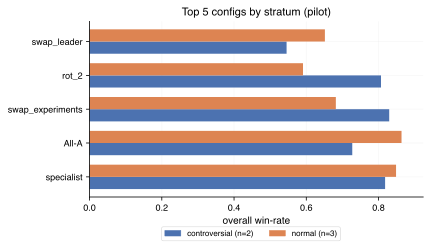

specialist vs All-A by stratum: controversial 0.818 vs 0.727; normal 0.848 vs 0.864 (Δ specialist contro−normal = -0.030)


In [8]:
from collections import defaultdict
from matplotlib.patches import Patch

DATASET = ROOT / "dataset" / "eval_sample_30.json"
paper_meta = {p["id"]: p for p in json.loads(DATASET.read_text())["papers"]}
STRATA = ("controversial", "normal")
STRATUM_COLORS = dict(zip(STRATA, PALETTE[:2]))
TOP_N = 5


def _points_for_config(verdict, favored_config, config_a, assistant_a_config):
    v = str(verdict).strip().upper()
    if v == "TIE":
        return 0.5
    if v not in {"A", "B"}:
        return 0.5
    assistant_a_won = v == "A"
    favored_is_assistant_a = favored_config == assistant_a_config
    return 1.0 if assistant_a_won == favored_is_assistant_a else 0.0


def win_rates_from_comparisons(comparisons, config_ids, dim="overall"):
    """Same macro-average as ``WinRateAggregator``, on a filtered comparison list."""
    pair_buckets: dict[str, list[float]] = defaultdict(list)
    for row in comparisons:
        pair_key = "__vs__".join(sorted((row["config_a"], row["config_b"])))
        pts = _points_for_config(
            row["verdicts"][dim],
            favored_config=row["config_a"],
            config_a=row["config_a"],
            assistant_a_config=row["assistant_a_config"],
        )
        pair_buckets[pair_key].append(pts)

    totals = {c: 0.0 for c in config_ids}
    counts = {c: 0 for c in config_ids}
    for pair_key, values in pair_buckets.items():
        a, b = pair_key.split("__vs__")
        score_a = float(np.mean(values))
        totals[a] += score_a
        totals[b] += 1.0 - score_a
        counts[a] += 1
        counts[b] += 1
    return {c: totals[c] / counts[c] if counts[c] else np.nan for c in config_ids}


by_stratum: dict[str, list[dict]] = {s: [] for s in STRATA}
for row in wr["raw_comparisons"]:
    by_stratum[paper_meta[row["paper_id"]]["stratum"]].append(row)

homo_by_config = df.set_index("config")["homogeneous"]
top_configs = df.nlargest(TOP_N, "win_rate")["config"].tolist()
config_ids = df["config"].tolist()

stratum_rows = []
for stratum in STRATA:
    comps = by_stratum[stratum]
    n_papers = len({row["paper_id"] for row in comps})
    rates = win_rates_from_comparisons(comps, config_ids)
    for config in config_ids:
        stratum_rows.append({
            "config": config,
            "stratum": stratum,
            "win_rate": rates[config],
            "n_papers": n_papers,
            "homogeneous": bool(homo_by_config[config]),
        })

df_stratum = pd.DataFrame(stratum_rows)
pivot = df_stratum.pivot(index="config", columns="stratum", values="win_rate")
pivot = pivot.reindex(top_configs)
pivot["delta (contro - normal)"] = pivot["controversial"] - pivot["normal"]

counts = df_stratum.groupby("stratum")["n_papers"].first()
print(f"Top {TOP_N} configs by overall win-rate — papers per stratum:", counts.to_dict())
display(
    pivot.assign(
        kind=np.where(pivot.index.map(homo_by_config), "reference", "heterogeneous")
    ).round(3)
)

# --- grouped bar chart (top configs only) ---
bar_h = 0.36
y = np.arange(len(pivot))
fig, ax = plt.subplots(figsize=FIG_COMPACT)
for i, stratum in enumerate(STRATA):
    offset = (i - 0.5) * bar_h
    vals = pivot[stratum].to_numpy()
    ax.barh(y + offset, vals, height=bar_h, color=STRATUM_COLORS[stratum], label=stratum)

x_lo = max(0.0, pivot.min().min() - 0.08)
x_hi = pivot.max().max() + 0.06
ax.set_xlim(x_lo, x_hi)
ax.set_yticks(y)
ax.set_yticklabels(pivot.index.tolist(), fontsize=9)
ax.set_xlabel("overall win-rate")
ax.set_title(fig_title(f"Top {TOP_N} configs by stratum"))
stratum_handles = [
    Patch(color=STRATUM_COLORS["controversial"], label=f"controversial (n={counts['controversial']})"),
    Patch(color=STRATUM_COLORS["normal"], label=f"normal (n={counts['normal']})"),
]
bottom = legend_below(
    fig,
    handles=stratum_handles,
    labels=[h.get_label() for h in stratum_handles],
    ncol=2,
)
save_fig(fig, FIG_DIR / "win_rate_by_stratum.png", bottom=bottom)
plt.show()

print(
    f"specialist vs All-A by stratum: "
    f"controversial {pivot.loc['specialist','controversial']:.3f} vs {pivot.loc['All-A','controversial']:.3f}; "
    f"normal {pivot.loc['specialist','normal']:.3f} vs {pivot.loc['All-A','normal']:.3f} "
    f"(Δ specialist contro−normal = {pivot.loc['specialist','delta (contro - normal)']:+.3f})"
)

## 6. Takeaways (pilot, single judge, n=5)

1. **The capability precondition dominates.** Homogeneous references spread enormously —
   `All-A` 0.81 ≫ `All-B` 0.21 ≫ `All-C` 0.02. Qwen runs away; Llama is on the floor.
   *Caveat:* `All-C` (Llama-as-leader) failed to delegate on 4/5 papers, so it degenerates
   to a stunted single-agent review — its 0.02 overstates the pure model gap.

2. **H1 barely holds and is likely within noise.** Only `specialist` (0.836) edges the best
   homogeneous `All-A` (0.809); head-to-head that is just 6 of 10 judgments. A ~0.03 margin on
   5 papers with one judge is **not** a significance claim — heterogeneity does not clearly beat
   "use the strongest single model everywhere".

3. **The clean signal is localization: `A`=qwen in the *experiments* seat is the winning move.**
   All three prune survivors (`specialist`, `swap_experiments`, `rot_2`) put A in experiments.
   The cleanest isolated case: `swap_experiments` (B,B,**A**,B) = 0.74 vs `All-B` = 0.21 — swapping
   *only* the experiments role Mistral→Qwen while the leader/writer stays Mistral jumps win-rate by
   half. The effect survives holding the final writer fixed, so it is not just leader writing style.

4. **Assignment matters, not just composition (Q2).** `specialist` beats `anti_specialist`
   ~10–0 head-to-head despite a similar model set — seating flips the outcome.
   *Soft caveat:* the multisets are not identical (`specialist` carries 2×A vs `anti`'s 1×A), so this
   partly conflates "better seats" with "more qwen".

5. **Seat-sensitivity ordering ≈ experiments > leader > clarity ≈ impact.**
   `swap_leader` (0.61) > `swap_clarity` (0.50) ≈ `swap_impact` (0.48); `rot_1` (0.21, A buried in
   clarity, C in impact) is the worst rotation. The leader seat helps, but the experiments seat helps most.

6. **Stratum slice is suggestive (n=2 vs n=3).** On **controversial** papers, heterogeneous configs
   (`swap_experiments`, `specialist`) lead and `All-A` drops to ~0.73; on **normal** papers `All-A`
   (~0.86) edges `specialist` (~0.85). If that pattern holds on `full`, heterogeneity may pay off
   mainly when human reviewers already disagree — worth pre-registering as a secondary read.

**Prune → Stage-2 `full` set:** keep the 3 references (`All-A/B/C`) + top-3 heterogeneous
(`specialist`, `swap_experiments`, `rot_2`) and score them on the held-out 25 papers with **two**
judges before any inference.